Import packages and prepare data
--------------------------------

In [184]:
import pandas as pd
import numpy as np
import thecannon as tc
import matplotlib.pyplot as plt

from scipy.optimize import Bounds

In [185]:
# Read in the training labels and model spectra
# These are 1000 samples of labels 'EWT','LMA','N','CHL','CAR','ANT'
# used to modelled spectra at wavelengths 400..1..2500nm with the PROSPECT code
LUC_labels  = pd.read_csv('PROSPECT_input.csv')
LUC_spectra = pd.read_csv('PROSPECT_LUT.csv')

These data include the following labels:

- EWT: Equivalent water thickness
- LMA: Dry matter content (DMC) equivalent
- CHL: chlorophyll
- CAR: carotenoids
- ANT: anthocyanins
- N: leaf structure parameter (integer, 1 through 4)

In [186]:
# Prepare input for a complete and restrictred Cannon model
prospect_wavelength_orig = np.arange(400,2501,1)
prospect_wavelength = np.arange(400, 2501, 525)

labels = ['EWT','LMA','N','CHL','CAR','ANT']
prospect_labels = np.array(LUC_labels[labels])
print(prospect_labels.shape)

labels_limited = ['EWT', ]#'LMA']
prospect_labels_limited = np.array(LUC_labels[labels_limited])

prospect_spectra = np.array(LUC_spectra).T

# Re-grid the training PROSPECT spectra
def recast_to_e2e(x):
    return np.interp(prospect_wavelength, prospect_wavelength_orig, x)

if len(prospect_wavelength) != len(prospect_wavelength_orig):
    prospect_spectra = np.apply_along_axis(
        recast_to_e2e, 1, np.asarray(prospect_spectra))

prospect_spectra_ivar = (100./prospect_spectra)**2.0 # SNR 100

for label in labels:
    print(f"{label:4s}: {np.min(LUC_labels[label]):.6e}, {np.max(LUC_labels[label]):.6e}")

print(prospect_spectra.shape)

(1000, 6)
EWT : 1.877323e-05, 5.997715e-02
LMA : 1.524955e-04, 5.987707e-02
N   : 1.005078e+00, 3.998169e+00
CHL : 2.424509e-01, 9.997812e+01
CAR : 2.172984e-02, 2.495823e+01
ANT : 2.470764e-03, 1.997834e+00
(1000, 5)


In [187]:
# We now want to make some 'blended' spectra. Let's make 1000 spectra by randomly blending N randomly selected original spectra
# Create and seed the random number generator
rng = np.random.default_rng(194)
no_to_blend = 5

new_spectra = np.zeros(prospect_spectra.shape)
new_spectra_ivar = np.zeros(prospect_spectra.shape)
new_labels = np.zeros(prospect_labels.shape)
new_labels_limited = np.zeros(prospect_labels_limited.shape)

for s in range(0, prospect_spectra.shape[0]):
    inds = rng.integers(prospect_spectra.shape[0], size=no_to_blend)
    facts = rng.random((no_to_blend, ))
    facts /= np.sum(facts)

    for i, (ind, fact) in enumerate(zip(inds, facts)):
        # Blend the spectra via summation (absolute flux values don't matter for TheCannon)
        new_spectra[s] += fact * prospect_spectra[ind]
        new_spectra_ivar[s] += fact * prospect_spectra_ivar[ind]

    # Work out the new labels via weighted average
    new_labels[s] = np.average(prospect_labels[inds], axis=0, weights=facts)
    new_labels_limited[s] = np.average(prospect_labels_limited[inds], axis=0, weights=facts)



In [188]:
prospect_spectra = new_spectra
prospect_spectra_ivar = new_spectra_ivar
prospect_labels = new_labels
prospect_labels_limited = new_labels_limited

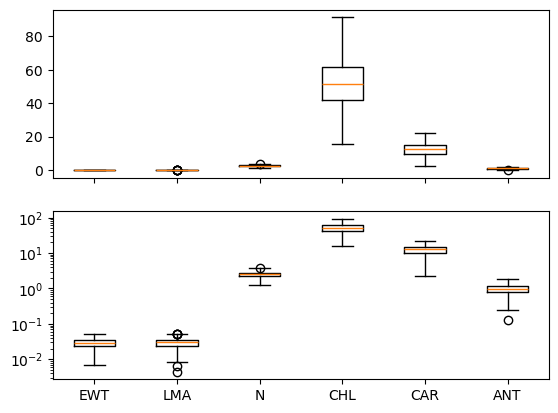

In [189]:
fig_initial = plt.figure()
ax_std = fig_initial.add_subplot(2, 1, 1)
ax_log = fig_initial.add_subplot(2, 1, 2)
ax_std.boxplot(prospect_labels)
ax_log.boxplot(prospect_labels)
ax_log.set_yscale("log")
ax_std.set_xticks(range(1, 7), "")
ax_log.set_xticks(range(1, 7), labels)

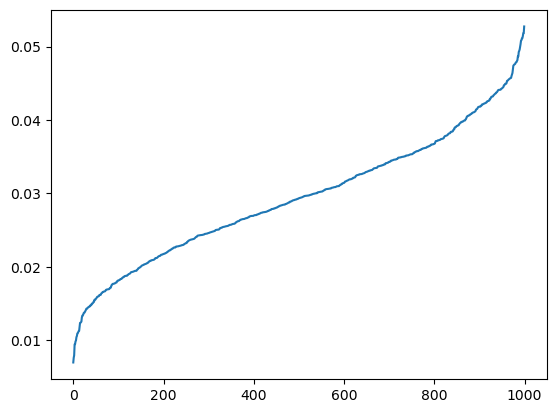

In [202]:
plt.plot(np.sort(prospect_labels[:,0]))

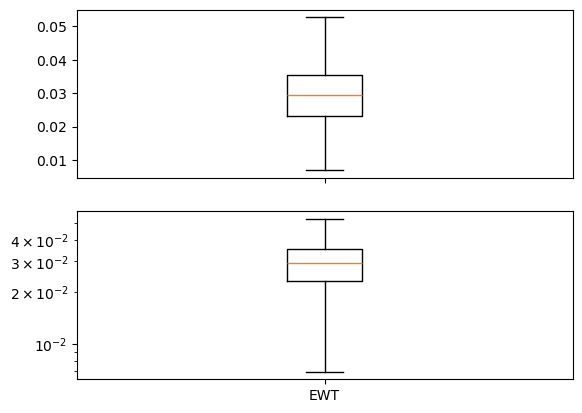

In [190]:
fig_initial = plt.figure()
ax_std = fig_initial.add_subplot(2, 1, 1)
ax_log = fig_initial.add_subplot(2, 1, 2)
ax_std.boxplot(prospect_labels_limited)
ax_log.boxplot(prospect_labels_limited)
ax_log.set_yscale("log")
ax_std.set_xticks(range(1, 2), "")
ax_log.set_xticks(range(1, 2), labels_limited)

In [191]:
prospect_spectra.shape

(1000, 5)

Generate 'all-up' basic model
-----------------------------

In [192]:
vec = tc.vectorizer.PolynomialVectorizer(list(labels[:3]), 2)
vec.get_human_readable_label_vector()

'1 + EWT + LMA + N + EWT^2 + EWT*LMA + EWT*N + LMA^2 + LMA*N + N^2'

In [193]:
# Initialise and train the complete Cannon Model
prospect_model = tc.CannonModel(
    prospect_labels,
    prospect_spectra, prospect_spectra_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(list(labels), 2),dispersion=prospect_wavelength)
prospect_theta, prospect_s2, prospect_metadata = prospect_model.train(threads=1)

2025-10-15 14:55:36,904 [INFO] Training 6-label CannonModel with 1000 input spectra and 5 pixels/spectrum
stty: stdin isn't a terminal
2025-10-15 14:55:36,928 [DEBUG] Couldn't get screen size. Progressbar may look odd.


[=====                                                                                               ] 100% (0s)                           


What we do here is the basic test step; we take the same spectra that we trained the model with, and see how well it recovers the labels that we know with certainty.

In [194]:
# Test the label recovery of the same spectra
prospect_test_labels, prospect_test_cov, prospect_metadata = prospect_model.test(prospect_spectra, prospect_spectra_ivar)

stty: stdin isn't a terminal
2025-10-15 14:55:36,992 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2025-10-15 14:55:36,992 [INFO] Running test step on 1000 spectra
2025-10-15 14:55:36,994 [ERROR] Exception within wrapped function
Traceback (most recent call last):
  File "/Users/mwhite/Documents/ozfuel/AnniesLasso/thecannon/utils.py", line 161, in __call__
    result = self.f(*(list(x) + self.args), **self.kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mwhite/Documents/ozfuel/AnniesLasso/thecannon/fitting.py", line 194, in fit_spectrum
    op_labels, cov, meta, mesg, ier = op.leastsq(
                                      ^^^^^^^^^^^
  File "/opt/anaconda3/envs/ozfuel3.12/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py", line 429, in leastsq
    raise TypeError(f"Improper input: func input vector length N={n} must"
TypeError: Improper input: func input vector length N=6 must not exceed func output vector length M=5


TypeError: Improper input: func input vector length N=6 must not exceed func output vector length M=5

In the plot below, the known input value is along the x-axis, and the recovered value from the test step is on the y-axis. For perfect recovery, all points should lie along the dashed line. The $\mu$ (mean) and $\sigma$ (standard deviation) shown on each plot is for the difference between the reference and training values.

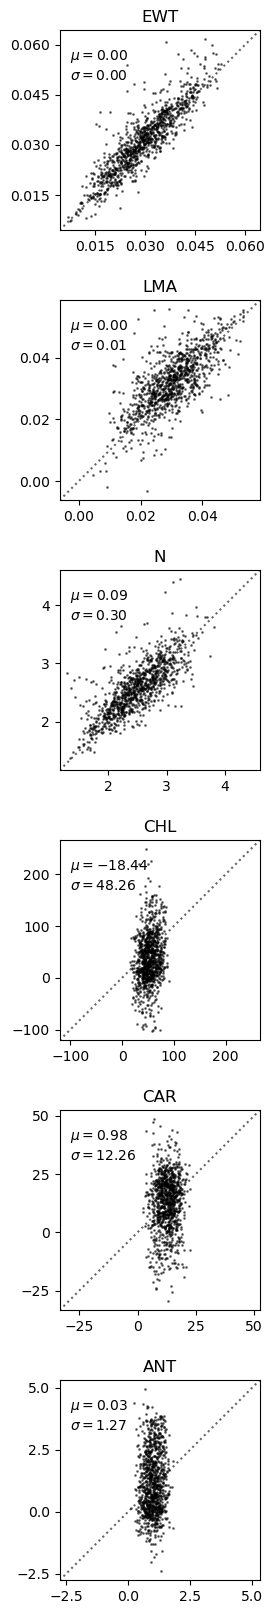

In [ ]:
fig_one_to_one = tc.plot.one_to_one(prospect_model, prospect_test_labels)

Generate a model limited to two labels
--------------------------------------

In [195]:
# Initialise and train the restricted Cannon Model
prospect_model_limited = tc.CannonModel(
    prospect_labels_limited,
    prospect_spectra, prospect_spectra_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(list(labels_limited), 2),dispersion=prospect_wavelength)
prospect_theta_limited, prospect_s2_limited, prospect_metadata_limited = prospect_model_limited.train(threads=1)

2025-10-15 14:55:45,556 [INFO] Training 1-label CannonModel with 1000 input spectra and 5 pixels/spectrum
stty: stdin isn't a terminal
2025-10-15 14:55:45,572 [DEBUG] Couldn't get screen size. Progressbar may look odd.


[=====                                                                                               ] 100% (0s)                           


In [196]:
# Test the label recovery of the same spectra
prospect_test_labels_limited, prospect_test_cov_limited, prospect_metadata_limited = prospect_model_limited.test(prospect_spectra, prospect_spectra_ivar)

stty: stdin isn't a terminal
2025-10-15 14:55:45,997 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2025-10-15 14:55:45,998 [INFO] Running test step on 1000 spectra


[=                                                                                                   ]   1% (14/1000)                          

[====================================================================================================] 100% (1s)                                


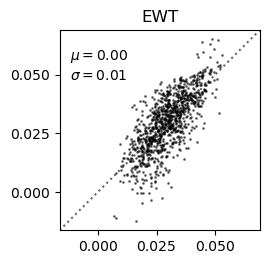

In [197]:
fig_one_to_one_limited = tc.plot.one_to_one(prospect_model_limited, prospect_test_labels_limited)

Run a restricted model
----------------------

So far, we've allowed every label to be completely free in fitting. However, this is unphysical; most of the labels (with the expcetion of `N`) have units weight per unit area, so they have a physical lower limit of 0.

Note that the theta limits in the `RestrictedCannonModel` are limits on the $`\theta`$ coefficient of the model for that term; they do **not** represent physical limits of the label value (a rookie mistake that the developer made for two weeks). Instead, to get limits on the output labels, one needs to send label bounds through to the `test` function.

By not specifying any `theta_bounds`, `RestrictedCannonModel` is equivalent to a standard `CannonModel`.

In [ ]:
# Initialise and train the restricted Cannon Model
from thecannon.restricted import RestrictedCannonModel
prospect_model_restricted = RestrictedCannonModel(
    prospect_labels,
    prospect_spectra, prospect_spectra_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(list(labels), 2),dispersion=prospect_wavelength)
# prospect_model_restricted.theta_bounds = {
#     t: (1e-9, None) for t in prospect_model_restricted.vectorizer.human_readable_label_vector.split(" + ")[1:]  # Ignore +1 term
# }
# prospect_model_restricted.theta_bounds["N"] = (1.0, 4.0)

prospect_theta_restricted, prospect_s2_restricted, prospect_metadata_restricted = prospect_model_restricted.train(threads=1)
print(prospect_model_restricted.theta_bounds)

2025-10-15 14:15:56,059 [INFO] Training 6-label RestrictedCannonModel with 1000 input spectra and 6 pixels/spectrum
stty: stdin isn't a terminal
2025-10-15 14:15:56,079 [DEBUG] Couldn't get screen size. Progressbar may look odd.


[======                                                                                              ] 100% (0s)                           
{}


In [ ]:
# %pdb
# Test the label recovery of the same spectra
bnds = ([-1 for l in prospect_model_restricted.vectorizer.label_names], [1000.0 for l in prospect_model_restricted.vectorizer.label_names])
prospect_test_labels_restricted, prospect_test_cov_restricted, prospect_metadata_restricted = prospect_model_restricted.test(
    prospect_spectra, prospect_spectra_ivar, 
    initial_labels=[0.01] * 6,
    op_kwds={"bounds": Bounds(
        lb=[1e-0 for label in prospect_model_restricted.vectorizer.label_names], 
        ub=[np.inf for label in prospect_model_restricted.vectorizer.label_names], 
        keep_feasible=[False for label in prospect_model_restricted.vectorizer.label_names])}
    )

stty: stdin isn't a terminal
2025-10-15 14:15:56,203 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2025-10-15 14:15:56,204 [INFO] Running test step on 1000 spectra


[====================================================================================================] 100% (6s)                                


In [ ]:
for i in range(prospect_test_labels_restricted.shape[1]):
    print(f"{i}: {np.min(prospect_test_labels_restricted[:, i])}")

0: 0.006686376652848866
1: -0.0033219613206653467
2: 1.272233124598823
3: -103.22537921674582
4: -29.54928110119429
5: -3.0101444908531096


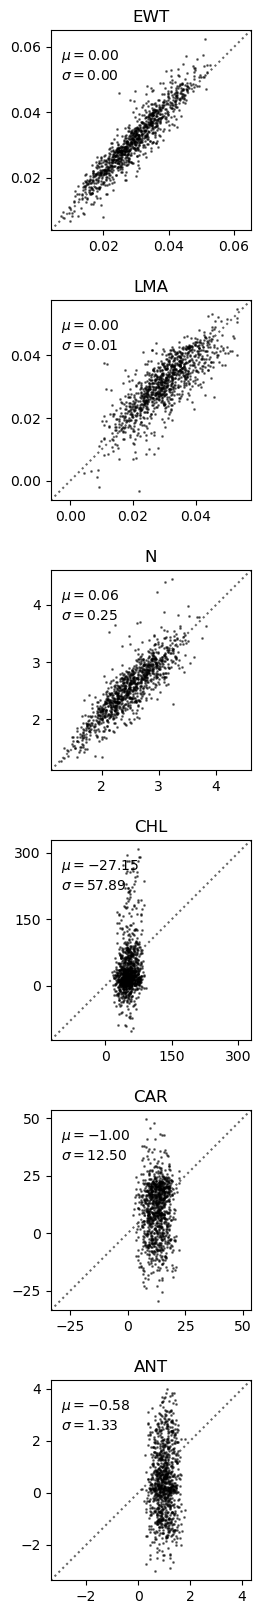

In [ ]:
fig_one_to_one_restricted = tc.plot.one_to_one(prospect_model_restricted, prospect_test_labels_restricted)